In [7]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../../')

In [8]:
from pathlib import Path
import math
import time
import random
import datetime
from functools import partial

import torch
import numpy as np
from PIL import Image
from einops import rearrange

%load_ext autoreload
%autoreload 2
    
from computer_vision.video_mae.pretrain_parameter_parser import parser
from computer_vision.video_mae.dataset.pretrained_datasets import HybridVideoMAE, DataAugmentationForVideoMAEv2
from computer_vision.video_mae.models.modeling_pretrain import PretrainVisionTransformer, pretrain_videomae_tiny_patch16_224
from computer_vision.video_mae.utils import seed_worker, multiple_pretrain_samples_collate, cosine_scheduler, get_grad_norm
from computer_vision.video_mae.optim_factory import create_optimizer
from computer_vision.video_mae.dataset.pretrained_datasets import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/trainlist01.txt'

mini_train=False
if not mini_train:
    output_dirpath=Path('D:/results/ucf101/video_mae/train') 
    arguments= f"""--data_root {root} --data_path {annotation_path} --output_dir {output_dirpath} 
    --mask_type tube --mask_ratio 0.9 --decoder_mask_type run_cell --decoder_mask_ratio 0.5
    --decoder_depth 4 --with_checkpoint --cos_attn --num_frame 16 --sampling_rate 4 --num_sample 1 
    --opt adamw --lr 6e-4 --clip_grad 0.02 --opt_betas 0.9 0.95 --warmup_epochs 30 
    --batch-size 24 --num_workers 0 --print_freq 30 --time 13
    --device cpu --epochs 300 --resume
    """ # --use-cutmix-mixup
else:
    output_dirpath=Path('D:/results/ucf101/video_mae/mini_train') 
    arguments= f"""--data_root {root} --data_path {annotation_path}  --output_dir {output_dirpath}  
    --mask_type tube --mask_ratio 0.9 --decoder_mask_type run_cell --decoder_mask_ratio 0.5
    --decoder_depth 4 --with_checkpoint --cos_attn --num_frame 16 --sampling_rate 4 --num_sample 1 
    --opt adamw --lr 6e-4 --clip_grad 0.02 --opt_betas 0.9 0.95 --warmup_epochs 30 
    --batch-size 24 --num_workers 0 --print_freq 20  --plot_freq 3
    --epochs 300 --device cpu --n_steps 60  --n_epochs 6 --time 0.5 --resume
    """ # --use-cutmix-mixup --time 18 --resume
args=parser.parse_args(arguments.split())


args.output_dir=Path(args.output_dir)
args.output_dir.mkdir(parents=True, exist_ok=True)
args.checkpoint_dir=args.output_dir/"checkpoints"
args.checkpoint_dir.mkdir(parents=True, exist_ok=True)
args.last=args.checkpoint_dir/args.last
args.best=args.checkpoint_dir/args.best
print(f"{args.last=}")
print(f"{args.best=}")

args.last=WindowsPath('D:/results/ucf101/video_mae/train/checkpoints/last.pth')
args.best=WindowsPath('D:/results/ucf101/video_mae/train/checkpoints/best.pth')


In [10]:
device=torch.device(args.device) if (torch.cuda.is_available() and args.device=='cuda') else torch.device('cpu')
print(f"{device=}")

torch.manual_seed(args.seed)
np.random.seed(args.seed)
random.seed(args.seed)

model=pretrain_videomae_tiny_patch16_224(args)

device=device(type='cpu')


In [11]:
model.encoder

PretrainVisionTransformerEncoder(
  (patch_embed): PatchEmbed(
    (proj): Conv3d(3, 192, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): CosAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=192, out_features=576, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=576, out_features=192, bias=True)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [12]:
model.encoder_to_decoder

Linear(in_features=192, out_features=128, bias=False)

In [13]:
model.decoder

PretrainVisionTransformerDecoder(
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (attn): CosAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=128, out_features=384, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=384, out_features=128, bias=True)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=1536, bias=True)
)

In [14]:

patch_size=model.encoder.patch_embed.patch_size
args.window_size=(args.num_frames//args.tubelet_size, args.input_size//patch_size[0], args.input_size//patch_size[1]) # T,H,W
args.patch_size=patch_size
print(f"Patch size {patch_size}, {args.window_size=}")

# build dataset
transform = DataAugmentationForVideoMAEv2(args)
train_dataset=HybridVideoMAE(root=args.data_root, setting=args.data_path, train=True, test_mode=False, name_pattern=args.fname_tmpl, 
                       video_ext='avi', is_color=True, modality='rgb', num_segments=1, num_crop=1, new_length=args.num_frames, 
                       new_step=args.sampling_rate, transform=transform, temporal_jitter=False, lazy_init=False, num_sample=args.num_sample)

num_training_steps_per_epoch=len(train_dataset)//args.batch_size
print(f"{num_training_steps_per_epoch=}")


collate_func=None
if args.num_sample>1: collate_func=partial(multiple_pretrain_samples_collate, fold=False)
num_devices=torch.cuda.device_count() # number of CUDA devices
# MUST KEEP args.num_workers to ZERO
train_dataloader=torch.utils.data.DataLoader(dataset=train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers, 
                                             pin_memory=num_devices>0 and args.pin_mem, drop_last=len(train_dataset)%args.batch_size!=0, 
                                             worker_init_fn=seed_worker, persistent_workers=args.num_workers>0, collate_fn=collate_func)

Patch size (16, 16), args.window_size=(8, 14, 14)
num_training_steps_per_epoch=397


In [15]:
tube_volume=args.tubelet_size*np.prod(args.patch_size)
tube_volume_value=args.tubelet_size*np.prod(args.patch_size)*3
number_of_tubes=np.prod(args.window_size)
print(f"{tube_volume=}, {tube_volume_value=}, {number_of_tubes=}")

tube_volume=np.int64(512), tube_volume_value=np.int64(1536), number_of_tubes=np.int64(1568)


In [16]:
checkpoint=None
if args.resume and args.last.is_file():
    checkpoint=torch.load(args.last, map_location='cpu', weights_only=False)
    print(f"Resume from checkpoint: {args.last}")
    model.load_state_dict(checkpoint['model'])

model.to(device)
model.eval();

Resume from checkpoint: D:\results\ucf101\video_mae\train\checkpoints\last.pth


In [17]:
data=next(iter(train_dataloader))
images, encoder_mask, decoder_mask=data
print(f"{type(images)=}, {images.shape=}, {images.dtype=}, ({images.min().item():.3f},{images.max().item():.3f})")
print(f"{type(encoder_mask)=}, {encoder_mask.shape=}, {encoder_mask.dtype=}, ({encoder_mask.min().item():.3f},{encoder_mask.max().item():.3f})")
print(f"{type(decoder_mask)=}, {decoder_mask.shape=}, {decoder_mask.dtype=}, ({decoder_mask.min().item():.3f},{decoder_mask.max().item():.3f})")
print(f"{args.num_sample*args.batch_size=}")

images=images.to(device, non_blocking=device.type=='cuda')
# from (B,Tp,Hp*Wp) to (B, Tp*Hp*Wp) where Tp is the number of tube in temporal dimension, Hp and Wp is the number of patches in H and W dimensions
encoder_mask=encoder_mask.to(device=device, dtype=torch.bool, non_blocking=device.type=='cuda').flatten(1) 
decoder_mask=decoder_mask.to(device=device, dtype=torch.bool, non_blocking=device.type=='cuda').flatten(1)

type(images)=<class 'torch.Tensor'>, images.shape=torch.Size([24, 3, 16, 224, 224]), images.dtype=torch.float32, (-2.118,2.640)
type(encoder_mask)=<class 'torch.Tensor'>, encoder_mask.shape=torch.Size([24, 8, 196]), encoder_mask.dtype=torch.uint8, (0.000,1.000)
type(decoder_mask)=<class 'torch.Tensor'>, decoder_mask.shape=torch.Size([24, 8, 196]), decoder_mask.dtype=torch.uint8, (0.000,1.000)
args.num_sample*args.batch_size=24


In [25]:
print(f"{encoder_mask.sum()=},{encoder_mask.numel()=}")
print(f"{decoder_mask.sum()=},{decoder_mask.numel()=}")

encoder_mask.sum()=tensor(33792),encoder_mask.numel()=37632
decoder_mask.sum()=tensor(18816),decoder_mask.numel()=37632


(np.float64(-0.5), np.float64(1357.5), np.float64(679.5), np.float64(-0.5))

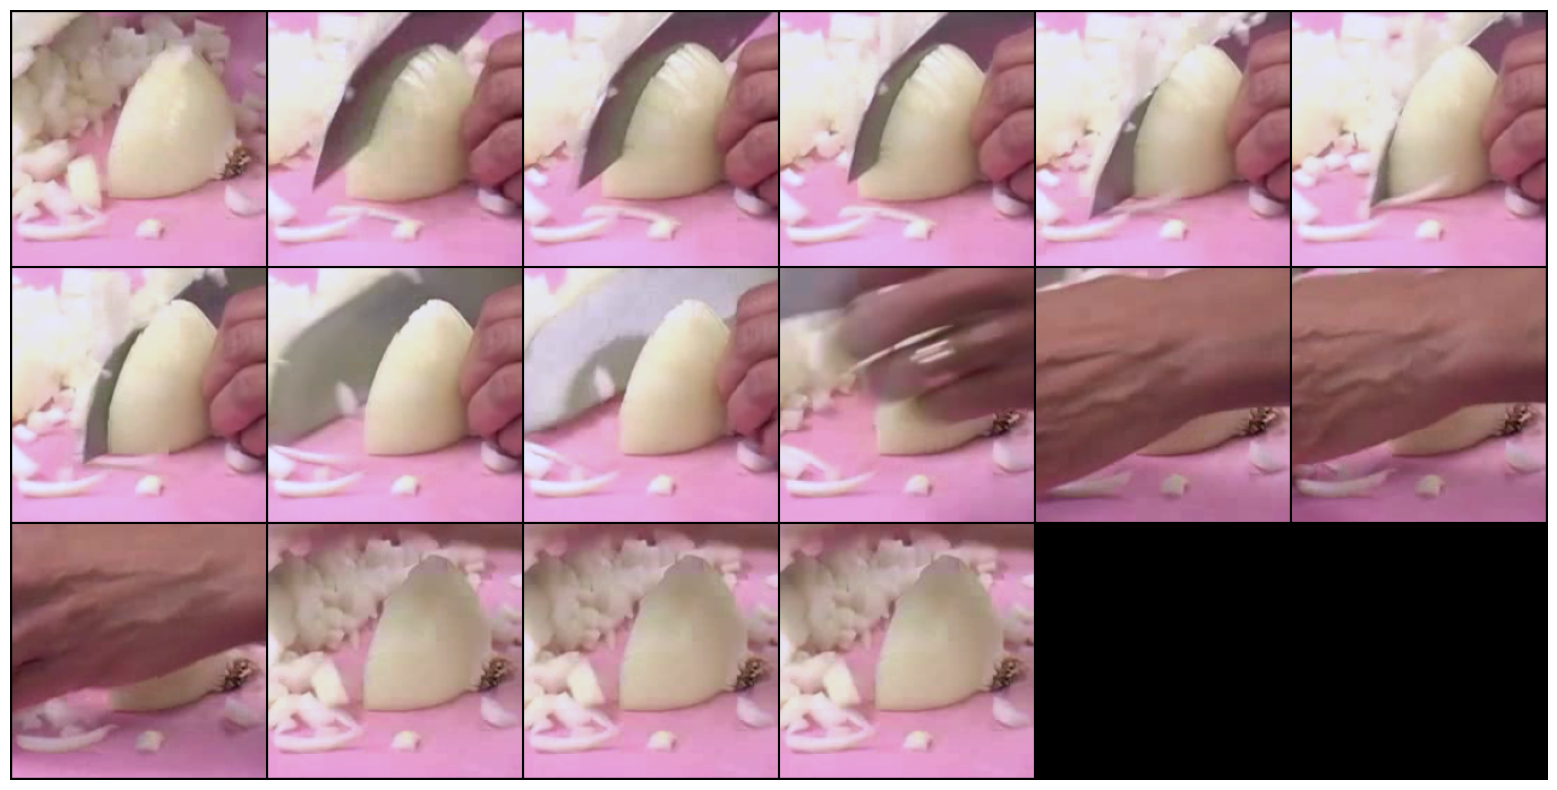

In [18]:
img_idx=0
plt.figure(figsize=(20,10))
plt.imshow(make_grid(images[img_idx].permute(1,0,2,3), normalize=True, nrow=6).permute(1,2,0))
plt.axis('off')


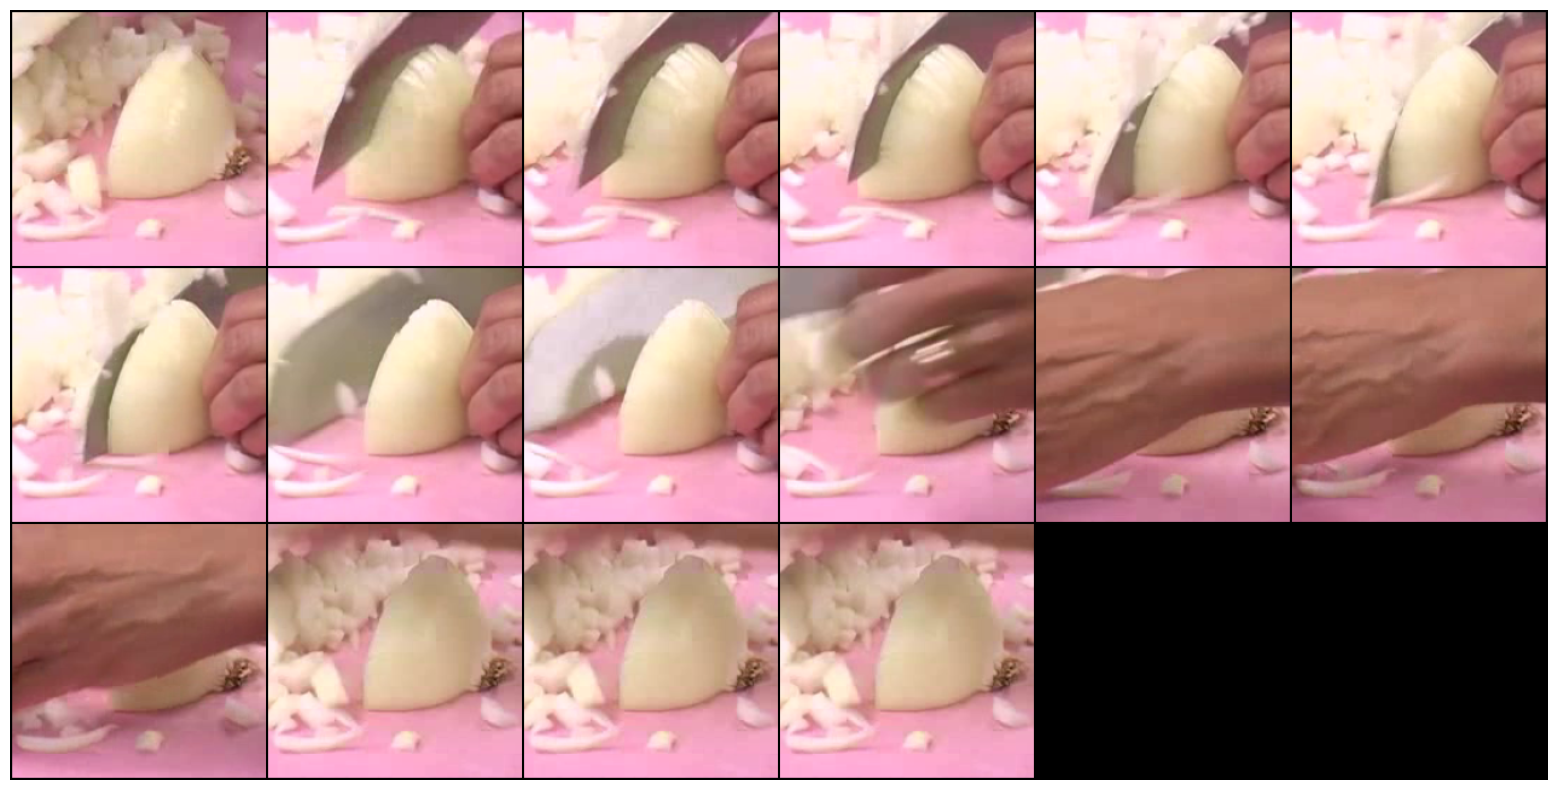

In [19]:
p0=args.tubelet_size
p1,p2=args.patch_size

mean=torch.as_tensor(IMAGENET_DEFAULT_MEAN)[None,:,None,None,None] # (1,3,1,1,1)
std=torch.as_tensor(IMAGENET_DEFAULT_STD)[None,:,None,None,None] # (1,3,1,1,1)

unnorm_images=images*std.to(device=images.device, dtype=images.dtype) + mean.to(device=images.device, dtype=images.dtype) # in [0,1]

plt.figure(figsize=(20,10))
plt.imshow(make_grid(unnorm_images[img_idx].permute(1,0,2,3), normalize=True, nrow=6).permute(1,2,0))
plt.axis('off')

# ---- reshape images from (B,C,T,H,W) to (B, t*h*w, p0*p1*p2, C)
B,C,T,H,W=unnorm_images.shape
t,h,w=T//p0,H//p1,W//p2
# split patch dimension
unnorm_images=unnorm_images.view(B,C,t,p0,h,p1,w,p2)
# reorder to (B,t,h,w,p0,p1,p2,C)
unnorm_images=unnorm_images.permute(0,2,4,6,3,5,7,1).contiguous()
# reshape to (B, t*h*w, p0*p1*p2, C) where t*h*w is the total number of patches/tokens and p0*p1*p2 is the total number of pixels per patch
unnorm_images=unnorm_images.view(B, t*h*w, p0*p1*p2, C)
if args.normalize_target:
    # -------normalize by patch mean and patch std (i.e., mean and std computed along the p0*p1*p2 dimension)
    images_norm=(unnorm_images-unnorm_images.mean(dim=-2, keepdim=True))/( unnorm_images.var(dim=-2, correction=1, keepdim=True).sqrt() +1e-6 )
    images_patch=images_norm.view(*images_norm.shape[:2], -1) # (B, t*h*w, p0*p1*p2*C)
    
    images_norm_=images_norm.view(B, t,h,w, p0,p1,p2, C)
    images_re=rearrange(images_norm_, 'b t h w p0 p1 p2 c -> b c (t p0) (h p1) (w p2)')
    
    images_norm_=images_norm_.permute(0,7,1,4,2,5,3,6).contiguous() # (B, t,h,w, p0,p1,p2, C) to (B,C,t,p0,h,p1,w,p2)
    images_=images_norm_.view(B,C,t*p0,h*p1,w*p2)

else:
    images_patch=unnorm_images.view(*unnorm_images.shape[:2], -1) # (B, t*h*w, p0*p1*p2*C

B, N, C = images_patch.shape
# decode_masked_pos of shape (B, t*h*w) and images_patch of shape (B, t*h*w, p0*p1*p2*C) so masking yield (something, p0*p1*p2*C)
labels=images_patch[~decoder_mask].reshape(B,-1,C) # (B,gt,C) where gt is the number of patches that get masked


(np.float64(-0.5), np.float64(1357.5), np.float64(679.5), np.float64(-0.5))

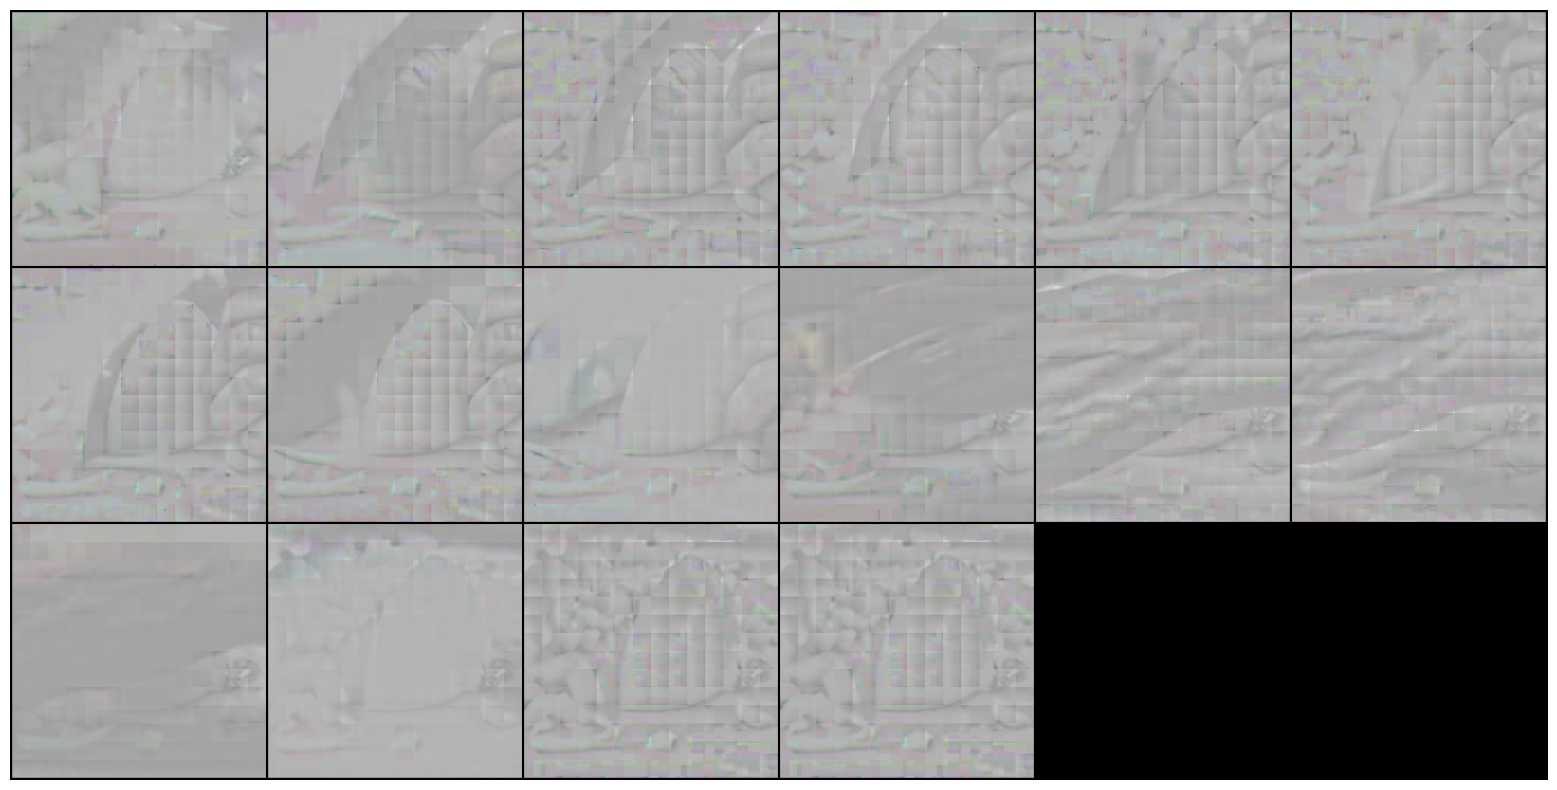

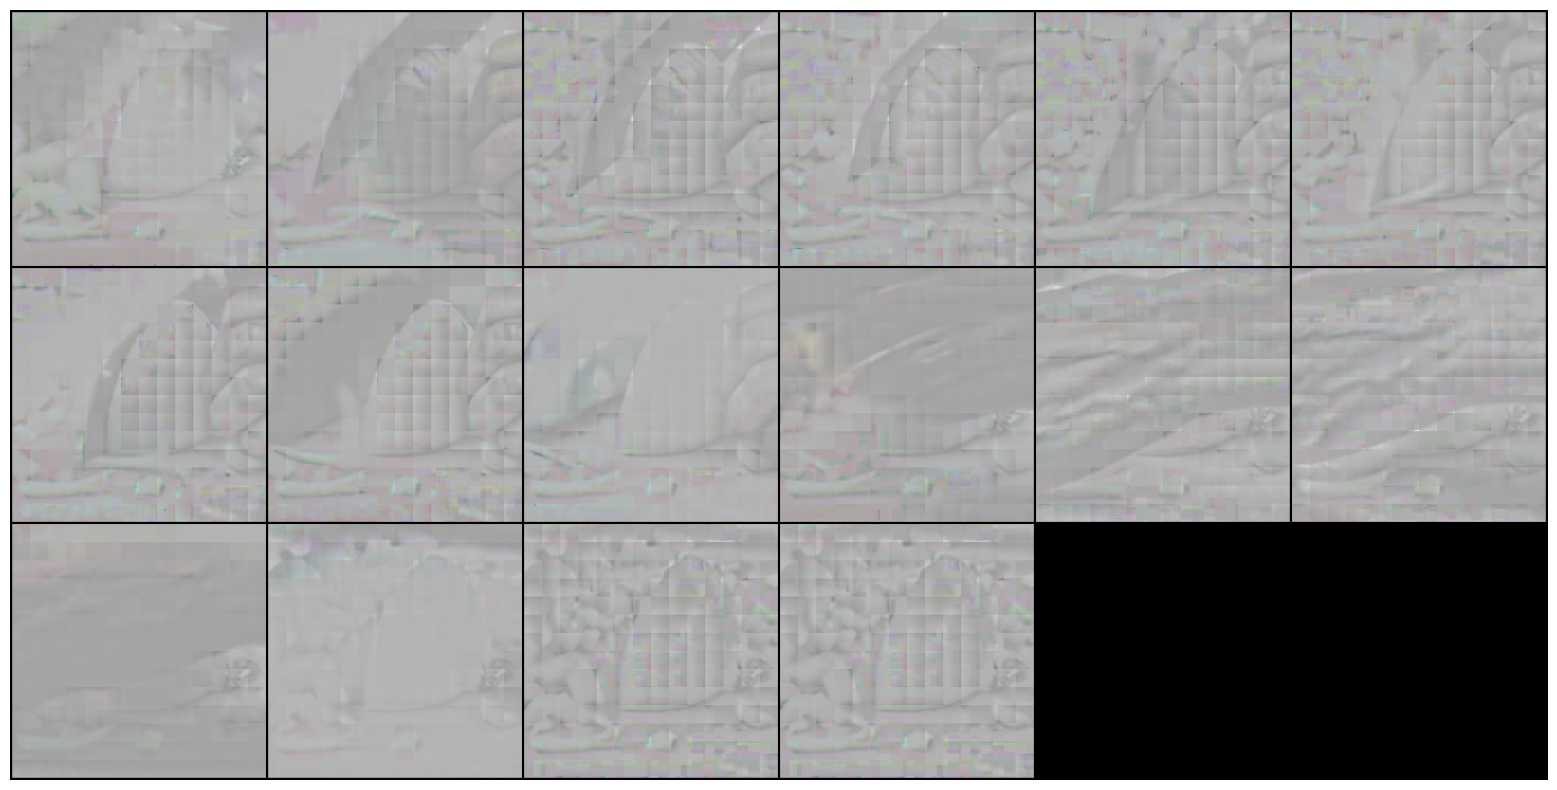

In [20]:

plt.figure(figsize=(20,10))
plt.imshow(make_grid(images_[img_idx].permute(1,0,2,3), normalize=True, nrow=6).permute(1,2,0))
plt.axis('off')

plt.figure(figsize=(20,10))
plt.imshow(make_grid(images_re[img_idx].permute(1,0,2,3), normalize=True, nrow=6).permute(1,2,0))
plt.axis('off')


In [21]:
with torch.no_grad(): outputs=model(images, encoder_mask, decoder_mask)

In [22]:
print(f"{labels.shape=}, {outputs.shape=}")
predicted_image_patch=images_patch.clone()
predicted_image_patch[~decoder_mask]=outputs.view(-1, outputs.shape[-1])
B,C,T,H,W=images.shape
predicted_image_patch=predicted_image_patch.view(B, t,h,w, p0,p1,p2, C)
predicted_image_patch=predicted_image_patch.permute(0,7,1,4,2,5,3,6).contiguous() # (B, t,h,w, p0,p1,p2, C) to (B,C,t,p0,h,p1,w,p2)
predicted_image_patch=predicted_image_patch.view(B,C,t*p0,h*p1,w*p2)
predicted_image_patch.shape

labels.shape=torch.Size([24, 784, 1536]), outputs.shape=torch.Size([24, 784, 1536])


torch.Size([24, 3, 16, 224, 224])

(np.float64(-0.5), np.float64(1357.5), np.float64(679.5), np.float64(-0.5))

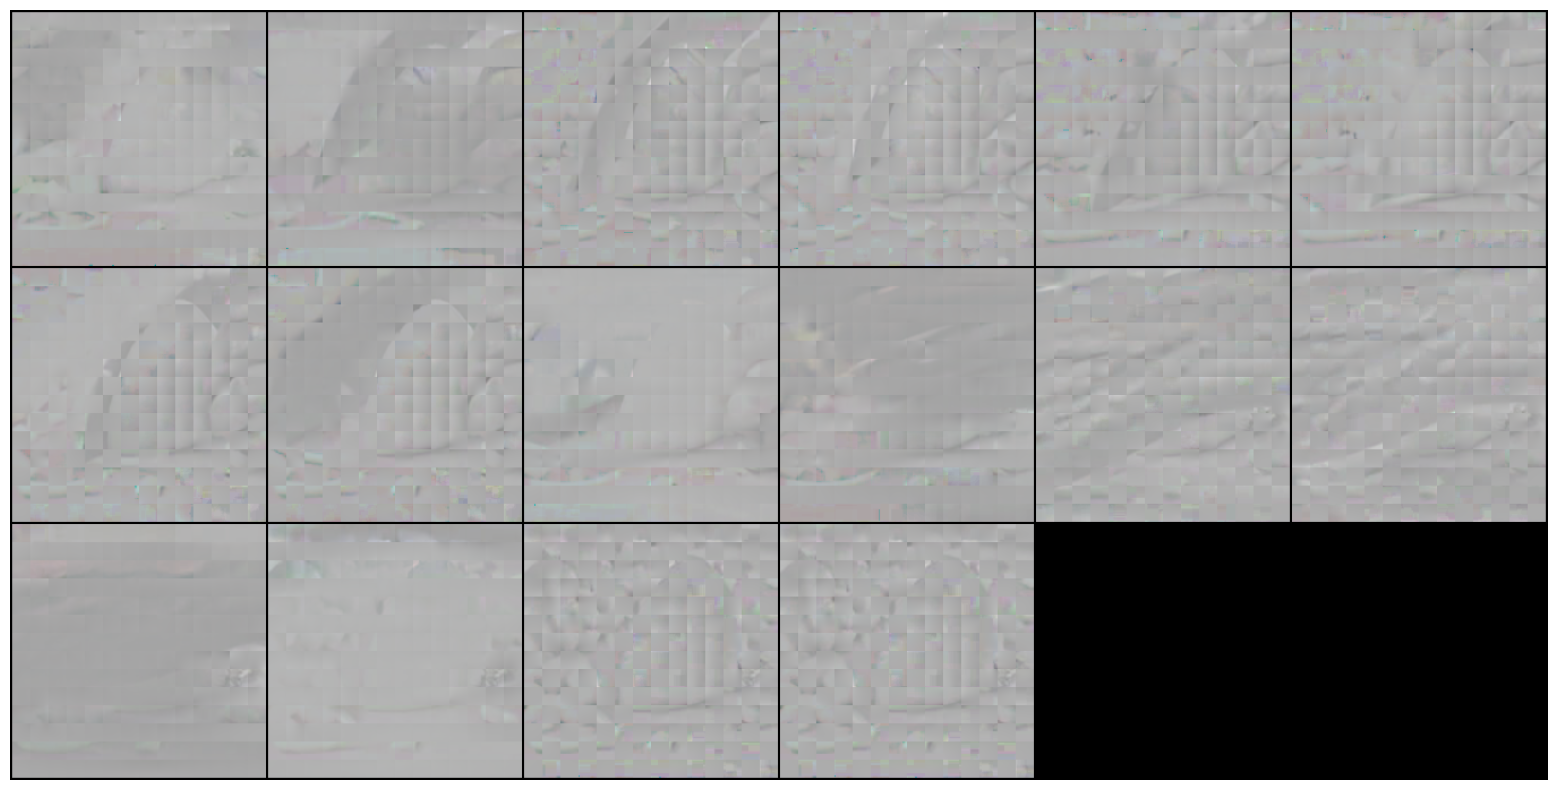

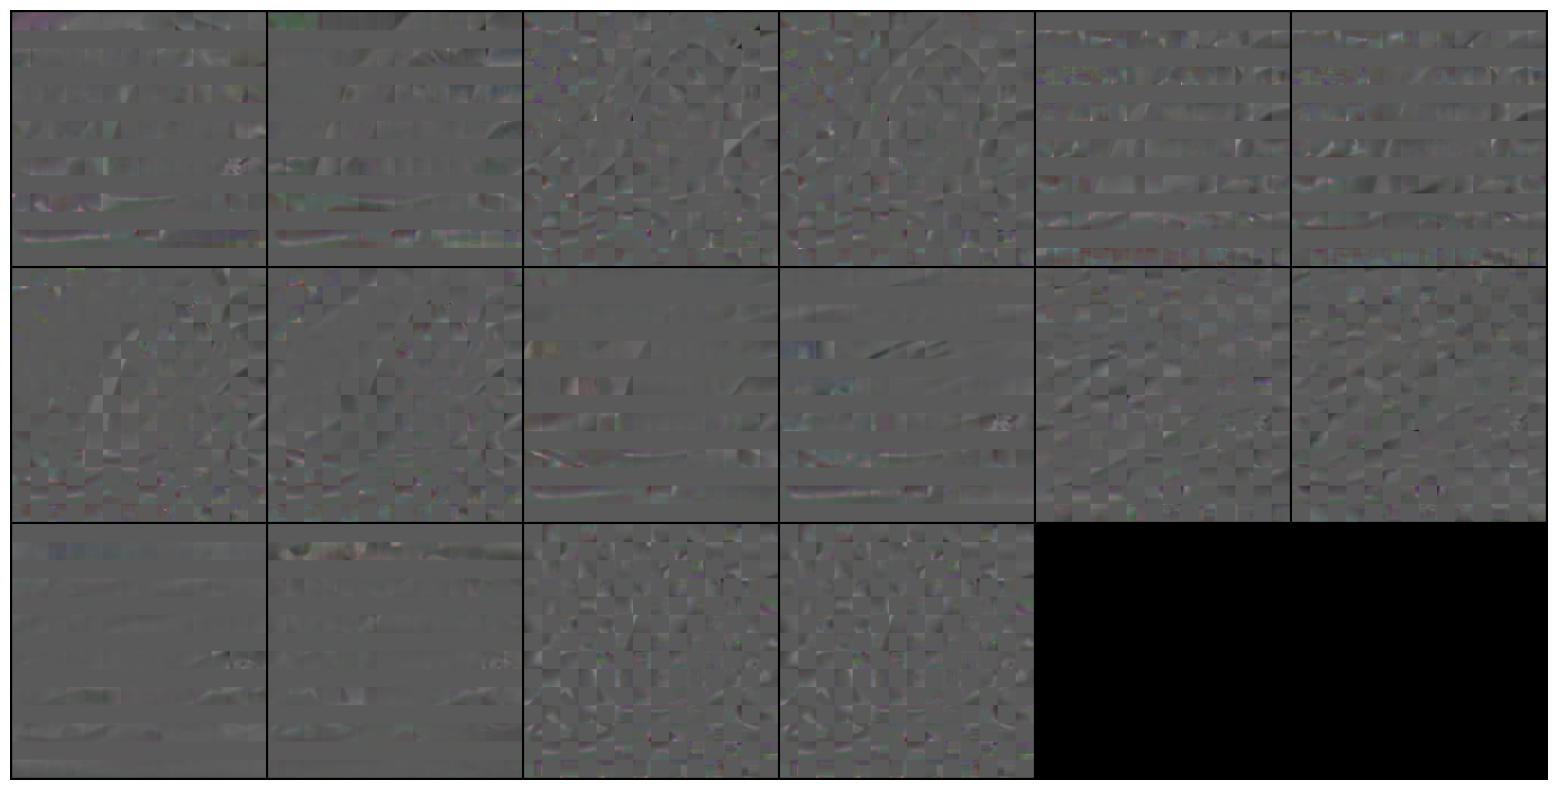

In [23]:
plt.figure(figsize=(20,10))
plt.imshow(make_grid(predicted_image_patch[img_idx].permute(1,0,2,3), normalize=True, nrow=6).permute(1,2,0))
plt.axis('off')

plt.figure(figsize=(20,10))
plt.imshow(make_grid((predicted_image_patch-images_)[img_idx].permute(1,0,2,3), normalize=True, nrow=6).permute(1,2,0))
plt.axis('off')

In [24]:
print(f"{predicted_image_patch.shape=}, {predicted_image_patch.dtype}, ({predicted_image_patch.min().item():.2f},{predicted_image_patch.max().item():.2f})")
print(f"{images_.shape=}, {images_.dtype}, ({images_.min().item():.2f},{images_.max().item():.2f})")
diff=predicted_image_patch-images_
print(f"{diff.shape=}, {diff.dtype}, ({diff.min().item():.2f},{diff.max().item():.2f})")

predicted_image_patch.shape=torch.Size([24, 3, 16, 224, 224]), torch.float32, (-22.45,19.35)
images_.shape=torch.Size([24, 3, 16, 224, 224]), torch.float32, (-22.45,22.52)
diff.shape=torch.Size([24, 3, 16, 224, 224]), torch.float32, (-21.61,16.73)
